# 00. Data Preparation

This notebook demonstrates the data pipeline for RTB iPinYou project:
1. Raw data exploration
2. Data preprocessing (parsing and unification)
3. Feature engineering
4. Train/Val/Test split

**Data Flow:**
```
Raw bz2 logs → Unified Parquet → Feature Engineering → Train/Val/Test splits
```

## 1. Setup

In [15]:
# Path configuration
import sys
from pathlib import Path

# Project root (1 level up from notebook)
PROJECT_ROOT = Path('.').absolute().parent
sys.path.insert(0, str(PROJECT_ROOT))

# Data paths
DATA_ROOT = PROJECT_ROOT / 'data' / 'ipinyou'
RAW_DIR = DATA_ROOT / 'raw' / 'ipinyou'
UNIFIED_DIR = DATA_ROOT / 'prediction' / 'unified'
FEATURES_DIR = DATA_ROOT / 'prediction' / 'features'

# Results paths
RESULTS_PATH = Path('.').absolute().parent / 'results'
FIG_PATH = RESULTS_PATH / 'figures'
TABLE_PATH = RESULTS_PATH / 'tables'

# Create directories if needed
FIG_PATH.mkdir(parents=True, exist_ok=True)
TABLE_PATH.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_ROOT: {DATA_ROOT}")
print(f"RESULTS_PATH: {RESULTS_PATH}")

PROJECT_ROOT: /Users/taehyun/project/rtb_ipinyou
DATA_ROOT: /Users/taehyun/project/rtb_ipinyou/data/ipinyou
RESULTS_PATH: /Users/taehyun/project/rtb_ipinyou/results


In [16]:
# Autoreload for development
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
# Standard libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Project modules
from src.data.parser import BID_SCHEMA, IMP_SCHEMA, list_log_files
from src.data.unifier import (
    load_from_parquet, 
    compute_dataset_stats,
    validate_unified_dataset,
)
from src.features import (
    get_feature_info,
    load_feature_splits,
)

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

SEED = 42
np.random.seed(SEED)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Raw Data Exploration

iPinYou RTB dataset structure:
- **bid logs**: All bid requests (lost + won)
- **imp logs**: Won impressions only
- **clk logs**: Clicked impressions
- **conv logs**: Converted clicks

In [18]:
# Check raw data structure
print("Raw data directory structure:")
print("="*50)

if RAW_DIR.exists():
    for season_dir in sorted(RAW_DIR.glob('training*')):
        print(f"\n{season_dir.name}/")
        files = list(season_dir.glob('*.bz2'))[:5]
        for f in files:
            print(f"  {f.name}")
        if len(list(season_dir.glob('*.bz2'))) > 5:
            print(f"  ... and {len(list(season_dir.glob('*.bz2'))) - 5} more files")
else:
    print(f"Raw data not found at {RAW_DIR}")
    print("Please download iPinYou dataset first.")

Raw data directory structure:

training1st/
  bid.20130313.txt.bz2
  conv.20130313.txt.bz2
  clk.20130317.txt.bz2
  imp.20130311.txt.bz2
  conv.20130312.txt.bz2
  ... and 23 more files

training2nd/
  clk.20130612.txt.bz2
  conv.20130606.txt.bz2
  bid.20130606.txt.bz2
  bid.20130607.txt.bz2
  conv.20130607.txt.bz2
  ... and 23 more files

training3rd/
  imp.20131024.txt.bz2
  clk.20131023.txt.bz2
  bid.20131027.txt.bz2
  bid.20131026.txt.bz2
  bid.20131019.txt.bz2
  ... and 28 more files


In [19]:
# Show bid log schema
print("Bid Log Schema (21 columns):")
print("="*50)
for i, col in enumerate(BID_SCHEMA.columns):
    dtype = BID_SCHEMA.dtypes.get(col, 'unknown')
    print(f"{i:2d}. {col:<20} ({dtype})")

Bid Log Schema (21 columns):
 0. bidid                (<class 'str'>)
 1. timestamp            (<class 'str'>)
 2. ipinyouid            (<class 'str'>)
 3. useragent            (<class 'str'>)
 4. ip                   (<class 'str'>)
 5. region               (Int64)
 6. city                 (Int64)
 7. adexchange           (Int64)
 8. domain               (<class 'str'>)
 9. url                  (<class 'str'>)
10. urlid                (<class 'str'>)
11. slotid               (<class 'str'>)
12. slotwidth            (Int64)
13. slotheight           (Int64)
14. slotvisibility       (Int64)
15. slotformat           (Int64)
16. slotprice            (Int64)
17. creative             (<class 'str'>)
18. bidprice             (Int64)
19. advertiser           (Int64)
20. usertag              (<class 'str'>)


In [20]:
# Show impression log schema (has additional columns)
print("\nImpression Log Schema (24 columns):")
print("="*50)
for i, col in enumerate(IMP_SCHEMA.columns):
    dtype = IMP_SCHEMA.dtypes.get(col, 'unknown')
    # Mark columns unique to imp logs
    marker = '*' if col not in BID_SCHEMA.columns else ' '
    print(f"{i:2d}.{marker}{col:<20} ({dtype})")
print("\n* = columns unique to impression/click/conversion logs")


Impression Log Schema (24 columns):
 0. bidid                (<class 'str'>)
 1. timestamp            (<class 'str'>)
 2.*logtype              (Int64)
 3. ipinyouid            (<class 'str'>)
 4. useragent            (<class 'str'>)
 5. ip                   (<class 'str'>)
 6. region               (Int64)
 7. city                 (Int64)
 8. adexchange           (Int64)
 9. domain               (<class 'str'>)
10. url                  (<class 'str'>)
11. urlid                (<class 'str'>)
12. slotid               (<class 'str'>)
13. slotwidth            (Int64)
14. slotheight           (Int64)
15. slotvisibility       (Int64)
16. slotformat           (Int64)
17. slotprice            (Int64)
18. creative             (<class 'str'>)
19. bidprice             (Int64)
20.*payprice             (Int64)
21.*keypageurl           (<class 'str'>)
22. advertiser           (Int64)
23. usertag              (<class 'str'>)

* = columns unique to impression/click/conversion logs


## 3. Run Preprocessing

Run the preprocessing script to create unified Parquet dataset.

```bash
# From project root:

python scripts/preprocess.py unify \
    --raw-dir data/ipinyou/raw/ipinyou \
    --output-dir data/ipinyou/prediction/unified \
    --seasons 2,3
    -- workers 14
```

workers: ray parallel

In [22]:
# Check if unified data exists
if UNIFIED_DIR.exists():
    print("Unified data found!")
    print(f"Location: {UNIFIED_DIR}")
    
    # List partitions
    partitions = list(UNIFIED_DIR.glob('*/*'))
    print(f"\nPartitions: {len(partitions)}")
    for p in partitions[:10]:
        print(f"  {p.relative_to(UNIFIED_DIR)}")
else:
    print("Unified data not found.")
    print("Run: python scripts/preprocess.py unify ...")

Unified data found!
Location: /Users/taehyun/project/rtb_ipinyou/data/ipinyou/prediction/unified

Partitions: 17
  season=3/day=20131020
  season=3/day=20131027
  season=3/day=20131019
  season=3/day=20131026
  season=3/day=20131021
  season=3/day=20131028
  season=3/day=20131024
  season=3/day=20131023
  season=3/day=20131022
  season=3/day=20131025


In [23]:
# Compute stats without loading full dataset into pandas
# (reads only 3 label columns via PyArrow → ~50x less memory than full load)
import pyarrow.parquet as pq
import pyarrow.compute as pc

if UNIFIED_DIR.exists():
    print("Computing unified data statistics...")
    table = pq.read_table(UNIFIED_DIR, columns=["win", "click", "conversion"])

    n_bids = table.num_rows
    n_imp = pc.sum(table.column("win")).as_py()
    n_clk = pc.sum(table.column("click")).as_py()
    n_conv = pc.sum(table.column("conversion")).as_py()
    del table  # free memory

    win_rate = n_imp / n_bids if n_bids > 0 else 0.0
    ctr = n_clk / n_imp if n_imp > 0 else 0.0
    cvr = n_conv / n_clk if n_clk > 0 else 0.0
    ctcvr = n_conv / n_imp if n_imp > 0 else 0.0

    print(f"\nDataset Statistics ({n_bids:,} rows):")
    print(f"  Total bids:    {n_bids:>12,}")
    print(f"  Impressions:   {n_imp:>12,}")
    print(f"  Clicks:        {n_clk:>12,}")
    print(f"  Conversions:   {n_conv:>12,}")
    print(f"  Win rate:      {win_rate:>12.2%}")
    print(f"  CTR:           {ctr:>12.4%}")
    print(f"  CVR:           {cvr:>12.2%}")
    print(f"  CTCVR:         {ctcvr:>12.6%}")

Computing unified data statistics...

Dataset Statistics (129,493,498 rows):
  Total bids:     129,493,498
  Impressions:     30,645,316
  Clicks:              23,058
  Conversions:          1,860
  Win rate:            23.67%
  CTR:                0.0752%
  CVR:                  8.07%
  CTCVR:            0.006069%


In [24]:
# Sample preview (reads one partition file only)
if UNIFIED_DIR.exists():
    parquet_files = sorted(UNIFIED_DIR.glob("**/*.parquet"))
    if parquet_files:
        df_sample = pd.read_parquet(parquet_files[0]).head()
        print("Sample rows (from one partition):")
        display(df_sample)
        print("\nColumn types:")
        display(df_sample.dtypes)

Sample rows (from one partition):


,bidid,timestamp,ipinyouid,useragent,ip,region,city,adexchange,domain,url,...,slotformat,slotprice,creative,bidprice,advertiser,usertag,win,click,conversion,payprice
0,b382c1c156dcbbd5b9317cb50f6a747b,20130606000104008,Vh16OwT6OQNUXbj,mozilla/4.0 (compatible; msie 6.0; windows nt ...,180.127.189.*,80,87,1,tFKETuqyMo1mjMp45SqfNX,249b2c34247d400ef1cd3c6bfda4f12a,...,1,0,00fccc64a1ee2809348509b7ac2a97a5,227,3427,None,0,0,0,0
1,7b6195de0d14203f92001da653bf1de,20130606000104009,Vhkr1vpROHuhQWB,Mozilla/4.0 (compatible; MSIE 8.0; Windows NT ...,113.119.105.*,216,217,2,trqRTuToMTNUjM9r5rMi,74419a072f8927222a1fd8aaa18cce56,...,0,5,2f88fc9cf0141b5bbaf251cab07f4ce7,300,3386,None,1,0,0,18
2,2ea9fe21cf7350fcb5696d8cff0bbeaa,20130606000104012,VhKdLnuY3tlhXMa,mozilla/4.0 (compatible; msie 8.0; windows nt ...,42.184.148.*,65,69,1,trqRTvpogNlyDok4JKTI,134db65c2b66d8468d00bf42fd9f912f,...,1,0,23d6dade7ed21cea308205b37594003e,227,3427,None,0,0,0,0
3,8a15b98c8f9e60d4f92aaab01acf52a4,20130606000104014,VhTVORqG36N6qMj,mozilla/5.0 (windows nt 5.1) applewebkit/537.1...,114.100.37.*,106,117,1,lsxSl559Xql7FmMs,8c9742e63497713b97ac7e780a8f9a12,...,1,0,23d6dade7ed21cea308205b37594003e,227,3427,"10063,10684,10083,13403,10059,10024,10048,1005...",1,0,0,207
4,faf17eac9cabf1be598f4e75f40d501d,20130606000104016,VhL01pk8OTkW3Mc,mozilla/5.0 (windows nt 5.1) applewebkit/537.1...,58.100.240.*,94,95,1,tK1NTu1YP5scFsf,e22930480589abcc1468854cb3403314,...,1,0,d5cecca9a6cbd7a0a48110f1306b26d1,227,3358,"10059,13866,10063,10111",1,0,0,108



Column types:


bidid             string[python]
timestamp         string[python]
ipinyouid         string[python]
useragent         string[python]
ip                string[python]
region                     Int64
city                       Int64
adexchange                 Int64
domain            string[python]
url               string[python]
urlid             string[python]
slotid            string[python]
slotwidth                  Int64
slotheight                 Int64
slotvisibility             Int64
slotformat                 Int64
slotprice                  Int64
creative          string[python]
bidprice                   Int64
advertiser                 Int64
usertag                   object
win                        int64
click                      int64
conversion                 int64
payprice                   Int64
dtype: object

## 4. Feature Engineering

Run feature building script:

```bash

python scripts/build_features.py build \
    --data-dir data/ipinyou/prediction/unified \
    --output-dir data/ipinyou/prediction/features \
    --split-method temporal \
    --workers 14
```

`--workers N`: Ray Parallel processing (feature engineering, usertag vocab)

### Feature Groups Overview

The feature engineering pipeline (`src/features/engineering.py`, `src/features/usertag.py`) transforms unified data into model-ready features organized in 5 groups:

| Group | Features | Why | Key Function |
|-------|----------|-----|--------------|
| **Time** | hour, minute, weekday, is_weekend, is_peak_hour, hour_sin, hour_cos | RTB 경쟁 강도와 사용자 행동이 시간대별로 다름 | `add_time_features()` |
| **Slot** | slot_area, slot_area_log, slot_aspect_ratio, slot_size_group | 광고 슬롯 크기/형태가 CTR과 경쟁 수준에 영향 | `add_slot_features()` |
| **Region** | region_freq, region_group, region_ctr (optional) | 지역별 경쟁 환경과 사용자 특성 차이 | `add_region_features()` |
| **Competition** | bid_floor_ratio, market_price_avg, market_price_std (optional) | 입찰 경쟁 강도가 win probability의 핵심 결정 요인 | `add_competition_features()` |
| **Usertag** | multi-hot sparse encoding (separate .npz) | 사용자 관심사 taxonomy → CTR/CVR 예측의 핵심 신호 | `encode_multihot_sparse()` |

> **Detailed reference**: [`docs/feature_dictionary.md`](../docs/feature_dictionary.md) — 각 feature의 what/why/how, 설계 결정, leakage 경고

### Key Design Decisions

1. **Cyclical encoding** (hour_sin/cos): hour 23과 hour 0의 유클리드 거리가 1이 되도록 sin/cos 변환. 트리 모델은 hour 정수를 직접 사용하지만, 신경망(ESCM2) 입력에서 주기성 보존 필수.

2. **IAB 표준 크기 매핑** (slot_size_group): `_SLOT_SIZE_MAP` 딕셔너리로 12개 표준 크기를 7개 그룹으로 매핑. `_SLOT_SIZE_LOOKUP` DataFrame으로 pre-build하여 vectorized merge 수행 (130M row에서 Python tuple 생성 회피).

3. **Log transform** (slot_area_log): `slot_area`는 right-skewed 분포 → `np.log1p` 변환으로 정규분포에 근사.

4. **Sparse usertag encoding**: Top-100 vocab, min_count=10. `scipy.sparse.csr_matrix`로 별도 .npz 파일 저장. Dense DataFrame에 포함하지 않아 메모리 효율 유지.

5. **Usertag leakage fix** (2026-02-12): `n_tags`/`has_tags` feature가 win label과 spurious 상관 (bid log usertag null → win=1만 tags 보유) → 제거. Win PS AUC 0.993 → ~0.91로 하락 (clean AUC).

> **Note**: 현재 로드된 데이터에 `n_tags`/`has_tags`가 잔존할 수 있음 — 코드에서 이미 제거되었으며 데이터 재빌드 시 사라짐.

In [25]:
# Check feature data
if FEATURES_DIR.exists():
    print("Feature data found!")
    
    # List files
    for f in sorted(FEATURES_DIR.glob('*.parquet')):
        size_mb = f.stat().st_size / 1024 / 1024
        print(f"  {f.name}: {size_mb:.1f} MB")
    
    # Load metadata
    import json
    meta_path = FEATURES_DIR / 'feature_metadata.json'
    if meta_path.exists():
        with open(meta_path) as f:
            meta = json.load(f)
        
        print("\nSplit sizes:")
        print(f"  Train: {meta['train_size']:,}")
        print(f"  Val:   {meta['val_size']:,}")
        print(f"  Test:  {meta['test_size']:,}")
        
        if 'feature_info' in meta:
            fi = meta['feature_info']
            print(f"\nFeatures: {fi['total_count']}")
            print(f"  Categorical: {len(fi['categorical'])}")
            print(f"  Numerical: {len(fi['numerical'])}")
else:
    print("Feature data not found.")
    print("Run: python scripts/build_features.py build ...")

Feature data found!
  test.parquet: 528.0 MB
  train.parquet: 2468.7 MB
  val.parquet: 547.9 MB

Split sizes:
  Train: 45,322,724
  Val:   9,712,012
  Test:  9,712,013

Features: 26
  Categorical: 2
  Numerical: 24


In [26]:
# Load and inspect feature data
if FEATURES_DIR.exists():
    train_df, val_df, test_df, metadata = load_feature_splits(FEATURES_DIR)
    
    print("Training set sample:")
    display(train_df.head())
    
    # Feature info
    feature_info = get_feature_info(train_df)
    print(f"\nFeature groups:")
    for group, features in feature_info.feature_groups.items():
        if features:
            print(f"  {group}: {features[:3]}..." if len(features) > 3 else f"  {group}: {features}")

Training set sample:


,bidid,timestamp,ipinyouid,region,city,adexchange,domain,slotid,slotwidth,slotheight,...,hour_cos,slot_area,slot_area_log,slot_aspect_ratio,slot_size_group,region_freq,region_group,bid_floor_ratio,n_tags,has_tags
0,b382c1c156dcbbd5b9317cb50f6a747b,20130606000104008,Vh16OwT6OQNUXbj,80,87,1,tFKETuqyMo1mjMp45SqfNX,mm_11402872_1272384_3182279,300,250,...,1.0,75000,11.225257,1.2,medium_rectangle,5409136,high,100.0,0,0
1,7b6195de0d14203f92001da653bf1de,20130606000104009,Vhkr1vpROHuhQWB,216,217,2,trqRTuToMTNUjM9r5rMi,433287550,468,60,...,1.0,28080,10.242848,7.8,banner,12181062,very_high,60.0,0,0
2,2ea9fe21cf7350fcb5696d8cff0bbeaa,20130606000104012,VhKdLnuY3tlhXMa,65,69,1,trqRTvpogNlyDok4JKTI,mm_10032051_2374052_9219530,950,90,...,1.0,85500,11.356283,10.56,other,892204,low,100.0,0,0
3,8a15b98c8f9e60d4f92aaab01acf52a4,20130606000104014,VhTVORqG36N6qMj,106,117,1,lsxSl559Xql7FmMs,mm_30232185_2681382_11190685,950,90,...,1.0,85500,11.356283,10.56,other,1724271,medium,100.0,18,1
4,faf17eac9cabf1be598f4e75f40d501d,20130606000104016,VhL01pk8OTkW3Mc,94,95,1,tK1NTu1YP5scFsf,mm_10075660_3500949_11453278,950,90,...,1.0,85500,11.356283,10.56,other,4282288,high,100.0,4,1



Feature groups:
  time: ['hour', 'minute', 'weekday']...
  slot: ['slot_area', 'slot_area_log', 'slot_aspect_ratio']...
  region: ['region', 'city', 'region_freq']...
  competition: ['bidprice', 'slotprice', 'bid_floor_ratio']
  id: ['adexchange', 'domain', 'advertiser']


In [ ]:
# Feature distribution visualizations
if 'train_df' in dir():
    # Sample for faster plotting (45M rows → 500K sample)
    sample = train_df.sample(n=min(500_000, len(train_df)), random_state=SEED)
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    
    # 1. Cyclical hour encoding — hour_sin vs hour_cos scatter
    ax = axes[0]
    scatter = ax.scatter(
        sample['hour_cos'], sample['hour_sin'],
        c=sample['hour'], cmap='hsv', alpha=0.3, s=1,
    )
    cbar = plt.colorbar(scatter, ax=ax, label='Hour')
    cbar.set_ticks([0, 6, 12, 18, 23])
    ax.set_xlabel('hour_cos')
    ax.set_ylabel('hour_sin')
    ax.set_title('Cyclical Hour Encoding')
    ax.set_aspect('equal')
    
    # 2. Slot size group distribution — bar chart
    ax = axes[1]
    group_counts = train_df['slot_size_group'].value_counts()
    colors = sns.color_palette('Set2', n_colors=len(group_counts))
    ax.barh(group_counts.index, group_counts.values, color=colors)
    ax.set_xlabel('Count')
    ax.set_title('Slot Size Group Distribution')
    ax.ticklabel_format(axis='x', style='scientific', scilimits=(6, 6))
    
    # 3. Bid floor ratio distribution — histogram
    ax = axes[2]
    # Clip for visualization (most values are concentrated)
    bfr = sample['bid_floor_ratio'].clip(upper=20)
    ax.hist(bfr, bins=50, alpha=0.7, edgecolor='white', linewidth=0.5)
    ax.set_xlabel('bid_floor_ratio (clipped at 20)')
    ax.set_ylabel('Count')
    ax.set_title('Bid Floor Ratio Distribution')
    ax.axvline(x=1.0, color='red', linestyle='--', alpha=0.7, label='ratio=1.0')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig(FIG_PATH / '00_feature_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    del sample

## 5. Split Statistics

Verify label distributions across splits.

In [27]:
if 'train_df' in dir():
    # Compute stats for each split
    splits = [('Train', train_df), ('Val', val_df), ('Test', test_df)]
    
    print("Label Distribution by Split:")
    print("="*70)
    print(f"{'Split':<10} {'N':>12} {'Win Rate':>12} {'CTR':>12} {'CVR':>12}")
    print("-"*70)
    
    for name, split_df in splits:
        stats = compute_dataset_stats(split_df)
        print(f"{name:<10} {stats.n_bids:>12,} {stats.win_rate:>12.2%} {stats.ctr:>12.4%} {stats.cvr:>12.2%}")

Label Distribution by Split:
Split                 N     Win Rate          CTR          CVR
----------------------------------------------------------------------
Train        45,322,724       20.99%      0.0697%        4.62%
Val           9,712,012       38.02%      0.0720%       10.53%
Test          9,712,013       21.80%      0.1058%       15.35%


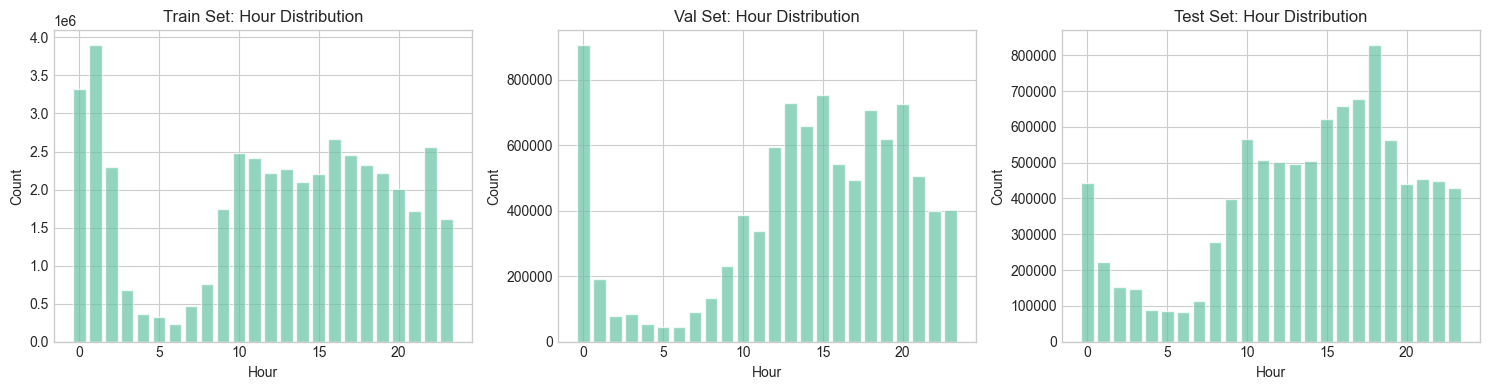

In [28]:
# Time distribution visualization
if 'train_df' in dir() and 'hour' in train_df.columns:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    for ax, (name, split_df) in zip(axes, splits):
        hour_dist = split_df['hour'].value_counts().sort_index()
        ax.bar(hour_dist.index, hour_dist.values, alpha=0.7)
        ax.set_xlabel('Hour')
        ax.set_ylabel('Count')
        ax.set_title(f'{name} Set: Hour Distribution')
    
    plt.tight_layout()
    plt.savefig(FIG_PATH / '00_hour_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

## Summary

Data pipeline complete. Key outputs:

| Output | Location | Description |
|--------|----------|-------------|
| Unified data | `prediction/unified/` | Partitioned Parquet (season/day) |
| Feature data | `prediction/features/` | Train/Val/Test splits |
| Vocabulary | `prediction/features/vocab/` | Usertag vocabulary |
| Statistics | `prediction/features/stats/` | Region/Market stats |

### Next Steps

1. `01_eda_analysis.ipynb`: Exploratory data analysis
2. `02_selection_bias_diagnosis.ipynb`: Bias quantification
3. `03_prediction_baseline.ipynb`: Train baseline models